In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

# 9. 데이터 그룹화 및 집계

In [2]:
from statsmodels.api import datasets
iris = datasets.get_rdataset('iris').data
iris

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


## 9.1 Group by
 - cf. pivot_table
 
 - df. groupby('label1')['label2'].func()
     - label1 : 기준이 된 열 이름
     - label2 : 생략 시 모든 열에 대해 적용
     - func() : 기초통계함수
 - 그룹화의 기준이 된 열 이름(column)은 그룹화 이후 행 이름(Index_Name)이 됨

In [7]:
# 'Species'별로 데이터를 그룹화한 뒤, 각 그룹의 합계 구하기
iris.groupby('Species').sum()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
versicolor,296.8,138.5,213.0,66.3
virginica,329.4,148.7,277.6,101.3


In [8]:
# 1) 그룹화 방법 1
# df.groupby('label1')['label2'].func() : laber1별로 그룹화한 뒤, laber2의 데이터 출력
# df.groupby('label1')[['label2','laber3']].func() : laber1별로 그룹화한 뒤, laber2, laber3의 데이터 출력
iris_grouped = iris.groupby('Species')
iris_grouped_sum = iris_grouped.sum()
iris_grouped_sum

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
versicolor,296.8,138.5,213.0,66.3
virginica,329.4,148.7,277.6,101.3


In [11]:
#iris_grouped_sum의 부분 조회 1
iris_grouped_sum.loc[['setosa', 'virginica']]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
virginica,329.4,148.7,277.6,101.3


In [12]:
# 그룹화의 기준이 된 열 이름(column)은 그룹화 이후 행 이름(Index_Name)이 됨
print(iris_grouped_sum.index)

Index(['setosa', 'versicolor', 'virginica'], dtype='object', name='Species')


In [14]:
iris_grouped_sum = iris_grouped_sum.reset_index()

In [15]:
iris_grouped_sum

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
1,versicolor,296.8,138.5,213.0,66.3
2,virginica,329.4,148.7,277.6,101.3


In [18]:
#iris_grouped_sum의 부분 조회 2
iris_grouped_sum[(iris_grouped_sum.Species=='setosa')|(iris_grouped_sum.Species=='virginica')]

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
2,virginica,329.4,148.7,277.6,101.3


In [19]:
#iris_grouped_sum의 부분 조회 3
iris_grouped_sum[iris_grouped_sum.Species.isin(['setosa', 'virginica'])]

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
2,virginica,329.4,148.7,277.6,101.3


In [20]:
# 1) 그룹화 방법 1-1 : 그룹핑 과정에서 index를 컬럼 데이터로 편입하기
# df.groupby(by='label1', as_index=False)['label2'].func()

iris.groupby('Species', as_index=False).sum()

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
1,versicolor,296.8,138.5,213.0,66.3
2,virginica,329.4,148.7,277.6,101.3


In [22]:
# 종별 Sepal.Length와 Sepal.Width의 평균
iris.groupby('Species').mean()[['Sepal.Length','Sepal.Width']]
iris.groupby('Species')[['Sepal.Length','Sepal.Width']].mean()

,Sepal.Length,Sepal.Width
Species,,
setosa,5.006,3.428
versicolor,5.936,2.770
virginica,6.588,2.974


In [24]:
# 종별 Sepal.Length의 합계
iris.groupby('Species')[['Sepal.Length']].sum()

,Sepal.Length
Species,
setosa,250.3
versicolor,296.8
virginica,329.4


- df.pivot_table(index='labels1',values='labels2',aggfunc='func')
    - label1 : 기준이 된 열 이름
    - label2 : 함수를 적용해 출력할 열 (생략 시 모든 열에 대해 적용)
    - aggfunc : 적용할 함수 (기본값 : mean)
    
* pivot_table - 오름차순으로 자동 정렬
* groupby() - 원본 열 순서 유지

In [27]:
# 그룹화 방법 2
# df.pivot_table(index='labels1',values='labels2',aggfunc='func')

g = iris.pivot_table(index='Species')
g

,Petal.Length,Petal.Width,Sepal.Length,Sepal.Width
Species,,,,
setosa,1.462,0.246,5.006,3.428
versicolor,4.260,1.326,5.936,2.770
virginica,5.552,2.026,6.588,2.974


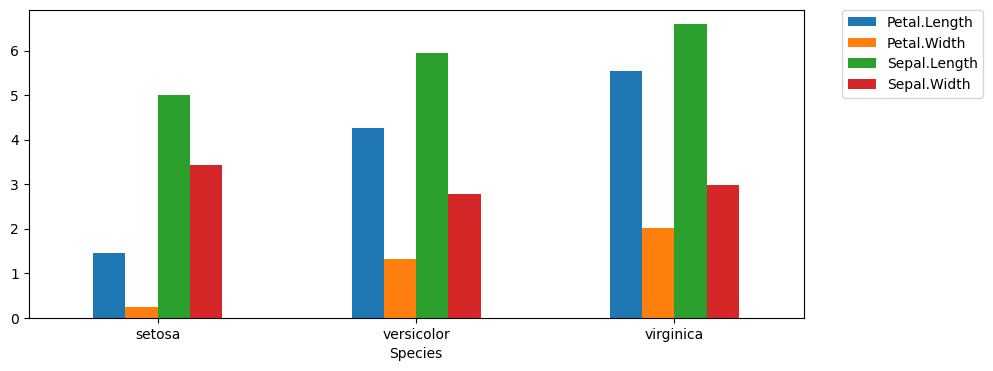

In [37]:
# 범례를 바깥으로 빼기
import matplotlib.pyplot as plt
g.plot(kind='bar', figsize=(10,4), rot=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

In [38]:
# pivot_talbe과 열 순서가 다름
g2 = iris.groupby('Species').mean()
g2

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


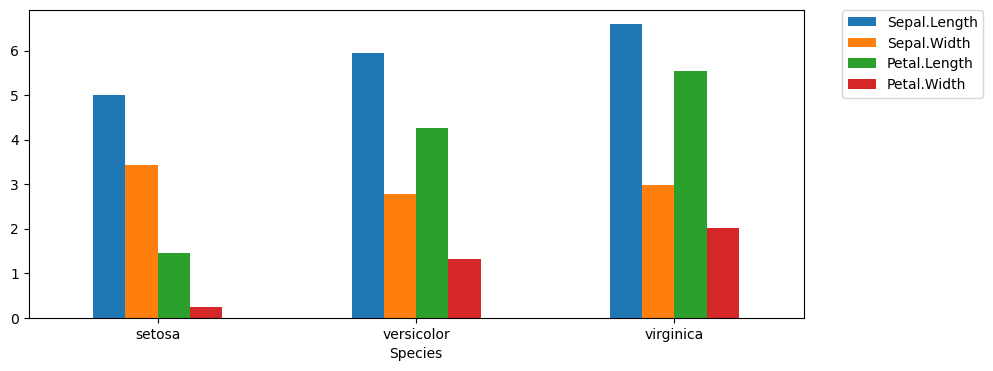

In [39]:
import matplotlib.pyplot as plt
g2.plot(kind='bar', figsize=(10,4), rot=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

In [40]:
iris.pivot_table(index='Species', # Species 별로 나눈 뒤
                values='Sepal.Length', # Sepal.Length 값들에게서
                aggfunc='count') # count 값을 반환

,Sepal.Length
Species,
setosa,50
versicolor,50
virginica,50


In [41]:
iris['Species'].value_counts() #count 값을 정렬하여 반환

setosa        50
versicolor    50
virginica     50
Name: Species, dtype: int64

In [46]:
# 임의의 각 열에 결측치 할당(0열 - 결측치 1 / 1열 - 결측치 2 / 2열 - 결측치 3 /...)
import numpy as np
import random


for col in range(iris.shape[1]-1): # iris의 열 수 - 1
    rows = random.sample(range(len(iris)), col+1)
    iris.iloc[rows, col] = np.nan

In [49]:
# 열별 결측치를 제외한 데이터 개수
iris.groupby('Species').count()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,49,49,49,49
versicolor,50,49,48,49
virginica,50,50,50,48


### 다중열 그룹화

In [59]:
#iris로 다중열 그룹화하기 위해 num 컬럼 추가 (150행 중, Species 3그룹, num 6그룹)

numbers = np.array([[i]*25 for i in range(6)]).flatten()

In [60]:
iris['num'] = numbers

In [61]:
# num 열 추가 확인
iris.head(1)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,num
0,5.1,3.5,1.4,0.2,setosa,0


In [72]:
# 2 level row index
r = iris.groupby(['Species','num']).sum()
r

Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species    num                                                      
setosa     0           125.7         87.0          36.5          5.9
           1           119.8         81.0          35.0          6.1
versicolor 2           150.3         69.4          99.9         33.6
           3           146.5         66.1         105.2         31.4
virginica  4           164.4         73.2         141.0         48.9
           5           165.0         75.5         136.6         47.8

In [76]:
# setosad와 virginica의 합계
r.loc[['setosa','virginica']]

Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species   num                                                      
setosa    0           125.7         87.0          36.5          5.9
          1           119.8         81.0          35.0          6.1
virginica 4           164.4         73.2         141.0         48.9
          5           165.0         75.5         136.6         47.8

In [77]:
# setosad, 0과 virginica, 5의 합계
r.loc[[('setosa',0),('virginica',5)]]

,,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,num,,,,
setosa,0,125.7,87.0,36.5,5.9
virginica,5,165.0,75.5,136.6,47.8


In [78]:
# 2 level row index
iris.pivot_table(index=['Species','num'])

Petal.Length  Petal.Width  Sepal.Length  Sepal.Width
Species    num                                                      
setosa     0        1.460000     0.245833      5.028000     3.480000
           1        1.458333     0.244000      4.991667     3.375000
versicolor 2        4.343478     1.344000      6.012000     2.776000
           3        4.208000     1.308333      5.860000     2.754167
virginica  4        5.640000     2.037500      6.576000     2.928000
           5        5.464000     1.991667      6.600000     3.020000

In [81]:
# 종별 요약통계량
iris.groupby(['Species']).describe().T

Species                setosa  versicolor  virginica
Sepal.Length count  49.000000   50.000000  50.000000
             mean    5.010204    5.936000   6.588000
             std     0.354874    0.516171   0.635880
             min     4.300000    4.900000   4.900000
             25%     4.800000    5.600000   6.225000
             50%     5.000000    5.900000   6.500000
             75%     5.200000    6.300000   6.900000
             max     5.800000    7.000000   7.900000
Sepal.Width  count  49.000000   49.000000  50.000000
             mean    3.428571    2.765306   2.974000
             std     0.382971    0.315272   0.322497
             min     2.300000    2.000000   2.200000
             25%     3.200000    2.500000   2.800000
             50%     3.400000    2.800000   3.000000
             75%     3.700000    3.000000   3.175000
             max     4.400000    3.400000   3.800000
Petal.Length count  49.000000   48.000000  50.000000
             mean    1.459184    4.272917   5.552000
             std     0.174306    0.456042   0.551895
             min     1.000000    3.000000   4.500000
             25%     1.400000    4.000000   5.100000
             50%     1.500000    4.350000   5.550000
             75%     1.500000    4.600000   5.875000
             max     1.900000    5.100000   6.900000
Petal.Width  count  49.000000   49.000000  48.000000
             mean    0.244898    1.326531   2.014583
             std     0.106186    0.199766   0.273659
             min     0.100000    1.000000   1.400000
             25%     0.200000    1.200000   1.800000
             50%     0.200000    1.300000   2.000000
             75%     0.300000    1.500000   2.300000
             max     0.600000    1.800000   2.500000
num          count  50.000000   50.000000  50.000000
             mean    0.500000    2.500000   4.500000
             std     0.505076    0.505076   0.505076
             min     0.000000    2.000000   4.000000
             25%     0.000000    2.000000   4.000000
             50%     0.500000    2.500000   4.500000
             75%     1.000000    3.000000   5.000000
             max     1.000000    3.000000   5.000000

## 9.2 그룹간 데이터 처리

In [2]:
from statsmodels.api import datasets
iris = datasets.get_rdataset('iris').data
iris.head(1)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa


In [3]:
iris_grouped = iris.groupby('Species')
list(iris_grouped) # 나열 가능한 자료 여부 확인

[('setosa',
      Sepal.Length  Sepal.Width  Petal.Length  Petal.Width Species
  0            5.1          3.5           1.4          0.2  setosa
  1            4.9          3.0           1.4          0.2  setosa
  2            4.7          3.2           1.3          0.2  setosa
  3            4.6          3.1           1.5          0.2  setosa
  4            5.0          3.6           1.4          0.2  setosa
  5            5.4          3.9           1.7          0.4  setosa
  6            4.6          3.4           1.4          0.3  setosa
  7            5.0          3.4           1.5          0.2  setosa
  8            4.4          2.9           1.4          0.2  setosa
  9            4.9          3.1           1.5          0.1  setosa
  10           5.4          3.7           1.5          0.2  setosa
  11           4.8          3.4           1.6          0.2  setosa
  12           4.8          3.0           1.4          0.1  setosa
  13           4.3          3.0           1.1     

In [10]:
for speciesname, group in iris_grouped:
    print(speciesname)
    display(group.sample(3).sort_index().reset_index(drop=True))

setosa


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,4.9,3.0,1.4,0.2,setosa
1,5.0,3.6,1.4,0.2,setosa
2,4.5,2.3,1.3,0.3,setosa


versicolor


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,6.7,3.1,4.4,1.4,versicolor
1,5.8,2.7,4.1,1.0,versicolor
2,6.1,2.8,4.0,1.3,versicolor


virginica


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,6.5,3.0,5.5,1.8,virginica
1,6.3,2.7,4.9,1.8,virginica
2,6.8,3.2,5.9,2.3,virginica


In [14]:
for speciesname, group in iris_grouped:
    print(speciesname)
    display(group.iloc[:45:15])

setosa


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
15,5.7,4.4,1.5,0.4,setosa
30,4.8,3.1,1.6,0.2,setosa


versicolor


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
50,7.0,3.2,4.7,1.4,versicolor
65,6.7,3.1,4.4,1.4,versicolor
80,5.5,2.4,3.8,1.1,versicolor


virginica


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
100,6.3,3.3,6.0,2.5,virginica
115,6.4,3.2,5.3,2.3,virginica
130,7.4,2.8,6.1,1.9,virginica


## 9.3 그룹별 인덱싱

In [18]:
iris.groupby('Species').take([0,15,30,45])

Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species                                                             
setosa     0             5.1          3.5           1.4          0.2
           15            5.7          4.4           1.5          0.4
           30            4.8          3.1           1.6          0.2
           45            4.8          3.0           1.4          0.3
versicolor 50            7.0          3.2           4.7          1.4
           65            6.7          3.1           4.4          1.4
           80            5.5          2.4           3.8          1.1
           95            5.7          3.0           4.2          1.2
virginica  100           6.3          3.3           6.0          2.5
           115           6.4          3.2           5.3          2.3
           130           7.4          2.8           6.1          1.9
           145           6.7          3.0           5.2          2.3

# 10. 데이터 구조 변경
- 와이드 포맷 ↔ 롱 포맷
    - 와이드 포맷 : 가로로 긴 형식의 데이터 구조
    - 롱 포맷 : 세로로 긴 형식의 데이터 구조
    
- melt()

In [29]:
from statsmodels.api import datasets
airquality = datasets.get_rdataset('airquality').data #1973년 뉴욕 공기질 데이터셋
airquality

,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.0,7.4,67,5,1
1,36.0,118.0,8.0,72,5,2
2,12.0,149.0,12.6,74,5,3
3,18.0,313.0,11.5,62,5,4
4,NaN,NaN,14.3,56,5,5
...,...,...,...,...,...,...
148,30.0,193.0,6.9,70,9,26
149,NaN,145.0,13.2,77,9,27
150,14.0,191.0,14.3,75,9,28
151,18.0,131.0,8.0,76,9,29


## 10.1 melt() 언피벗팅
- 와이드 포맷 → 롱 포맷
- df.melt(id_vals, value_vars, var_name, value_name)
- pd.melt(df, id_vars, value_vars, var_name, value_name)

In [30]:
airquality_melted =  airquality.melt(id_vars=['Month', 'Day'],
                                    #value_vars=['Ozone', 'Solar.R', 'Wind', 'Temp']
                                    )
airquality_melted

,Month,Day,variable,value
0,5,1,Ozone,41.0
1,5,2,Ozone,36.0
2,5,3,Ozone,12.0
3,5,4,Ozone,18.0
4,5,5,Ozone,NaN
...,...,...,...,...
607,9,26,Temp,70.0
608,9,27,Temp,77.0
609,9,28,Temp,75.0
610,9,29,Temp,76.0


In [36]:
airquality_melted =  airquality.melt(id_vars=['Month', 'Day'],
                                    var_name='변수명', # melt된 데이터의 열 이름
                                    value_name='값'
                                    )
airquality_melted = airquality_melted.sort_values(by=['Month', 'Day']).reset_index(drop=True)

## 10.2 pivot_table() 피벗팅
- 롱 포맷 → 와이드 포맷
- df.pivot_table(index, columns, values)
- pd.pivot_table(df, index, columns, values)

In [45]:
airquality2 = airquality_melted.pivot_table(index=['Month', 'Day'],
                             columns=['변수명'],
                             #values='값'
                                           )
airquality2.columns = airquality2.columns.droplevel(level=0) # columns의 level 조정하기
airquality2.columns.name = None # columns의 name 제거
airquality2 = airquality2.reset_index()
airquality2

,Month,Day,Ozone,Solar.R,Temp,Wind
0,5,1,41.0,190.0,67.0,7.4
1,5,2,36.0,118.0,72.0,8.0
2,5,3,12.0,149.0,74.0,12.6
3,5,4,18.0,313.0,62.0,11.5
4,5,5,NaN,NaN,56.0,14.3
...,...,...,...,...,...,...
148,9,26,30.0,193.0,70.0,6.9
149,9,27,NaN,145.0,77.0,13.2
150,9,28,14.0,191.0,75.0,14.3
151,9,29,18.0,131.0,76.0,8.0


# 11. 데이터 프레임 함수
- apply(func, axis)
    - 시리즈: 요소별 func 적용
    - 데이터프레임: 행(axis=1) 또는 열(axis=0) 단위 func 적용
- map(func) : 각 요소별 func 적용 (시리즈만 적용 가능)
- applymap(func) : 각 요소별 func 적용 (데이터 프레임만 적용 가능)

## 11.1 apply() / map() 

In [50]:
import pandas as pd
member = pd.read_csv('data/ch11_member.csv', comment='#')
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [51]:
get_year = lambda datestr : int(datestr.split('-')[0])
get_month = lambda datestr : int(datestr.split('-')[1])

In [58]:
# 시리즈에서의 apply / map 사용
member['Year'] = member['Birth'].map(lambda datestr : int(datestr.split('-')[0]))
member['Month'] = member['Birth'].apply(lambda datestr : int(datestr.split('-')[1]))

In [59]:
member

,Name,Age,Email,Address,Birth,Year,Month
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,1999,1
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,1999,12
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,1999,11
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,1999,5
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,1999,1


In [63]:
%ls "C:/ai/downloads/shareData/분양가격"

 C 드라이브의 볼륨에는 이름이 없습니다.
 볼륨 일련 번호: 0C81-36F7

 C:\ai\downloads\shareData\분양가격 디렉터리

2026-07-14  오후 05:36    <DIR>          .
2026-07-14  오후 05:46    <DIR>          ..
2026-06-24  오후 10:04             2,163 전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv
2026-07-14  오후 05:36           501,367 주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20260531 (1).csv
               2개 파일             503,530 바이트
               2개 디렉터리  137,184,280,576 바이트 남음


In [65]:
df_last = pd.read_csv('C:/ai/downloads/shareData/분양가격/주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20260531 (1).csv', encoding = 'cp949')
df_last.head()

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
0,서울,모든면적,2015,10,5841
1,서울,전용면적 60제곱미터이하,2015,10,5652
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721
4,서울,전용면적 102제곱미터초과,2015,10,5879


In [72]:
def year_month(series):
    return "{}-{:02}".format(series['연도'], series['월'])
#    return str(series['연도'])+"-"+(str(series['월']) if series['월']>=10 else ("0"+str(series['월'])))
year_month(df_last.loc[300])

'2016-01'

In [73]:
# 데이터 프레임에서의 apply(func, axis) 사용
df_last['연월'] = df_last.apply(year_month, axis = 1)
df_last.tail()

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),연월
10875,제주,모든면적,2026,5,4473,2026-05
10876,제주,전용면적 60제곱미터이하,2026,5,NaN,2026-05
10877,제주,전용면적 60제곱미터초과 85제곱미터이하,2026,5,4485,2026-05
10878,제주,전용면적 85제곱미터초과 102제곱미터이하,2026,5,NaN,2026-05
10879,제주,전용면적 102제곱미터초과,2026,5,4350,2026-05


In [75]:
import numpy as np
X = iris.iloc[:,:-1]
avg = np.mean(X, axis = 0)
avg = X.mean()
avg

Sepal.Length    5.843333
Sepal.Width     3.057333
Petal.Length    3.758000
Petal.Width     1.199333
dtype: float64

In [76]:
# 각 열별 평균과의 차이를 출력
X.apply(lambda x : x - avg, axis = 1)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,-0.743333,0.442667,-2.358,-0.999333
1,-0.943333,-0.057333,-2.358,-0.999333
2,-1.143333,0.142667,-2.458,-0.999333
3,-1.243333,0.042667,-2.258,-0.999333
4,-0.843333,0.542667,-2.358,-0.999333
...,...,...,...,...
145,0.856667,-0.057333,1.442,1.100667
146,0.456667,-0.557333,1.242,0.700667
147,0.656667,-0.057333,1.442,0.800667
148,0.356667,0.342667,1.642,1.100667


## 11.2 applymap()

In [84]:
X.applymap(lambda x : round(x, 2))

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


### 함수 적용시키기 연습 예제
* 2013~2015
    * 와이드포맷 → 롱포맷
    * 평당 분양가격 / 3.3  → 분양가격 (제곱미터당 천원)
    * 2013년12월 → 연도 : 2013, 월 : 12
    * 지역 → 지역명
* 2015~
    * 규모구분 '모든면적' 데이터만 추출
* 2013~
    * 두 자료 합치기

In [179]:
df_last = pd.read_csv('C:/ai/downloads/shareData/분양가격/주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20260531 (1).csv', encoding = 'cp949')
df_last.head()

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
0,서울,모든면적,2015,10,5841
1,서울,전용면적 60제곱미터이하,2015,10,5652
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721
4,서울,전용면적 102제곱미터초과,2015,10,5879


In [177]:
df_first = pd.read_csv('c:/ai/downloads/shareData/분양가격/전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv', encoding='cp949')
df_first.head()

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,2014년10월,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,19404,19759,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443
1,부산,8111,8111,9078,8965,9402,9501,9453,9457,9411,9258,9110,9208,9208,9204,9235,9279,9327,9345,9515,9559,9581
2,대구,8080,8080,8077,8101,8267,8274,8360,8360,8370,8449,8403,8439,8253,8327,8416,8441,8446,8568,8542,8542,8795
3,인천,10204,10204,10408,10408,10000,9844,10058,9974,9973,9973,10016,10020,10020,10017,9876,9876,9938,10551,10443,10443,10449
4,광주,6098,7326,7611,7346,7346,7523,7659,7612,7622,7802,7707,7752,7748,7752,7756,7861,7914,7877,7881,8089,8231


In [178]:
df_first_melted = df_first.melt(id_vars='지역',
                                var_name='연월',
                                value_name='분양가격')
df_first_melted.head()

,지역,연월,분양가격
0,서울,2013년12월,18189
1,부산,2013년12월,8111
2,대구,2013년12월,8080
3,인천,2013년12월,10204
4,광주,2013년12월,6098


In [180]:
df_first_melted['연도'] = df_first_melted['연월'].map(lambda datestr : int(datestr[:4]))
df_first_melted['월'] = df_first_melted['연월'].map(lambda datestr : int(datestr[5:-1]))

In [181]:
df_first_melted['분양가격(제곱미터당 천원)'] = df_first_melted['분양가격'].map(lambda x : int(round( x / 3.3)))

In [182]:
df_first_melted = df_first_melted.drop('분양가격', axis=1)

In [183]:
df_first_melted = df_first_melted.drop('연월', axis=1)
df_first_melted['지역명'] = df_first_melted['지역']
df_first_melted = df_first_melted.drop('지역', axis=1)
# df_first_melted.rename(columns={'지역':'지역명'}, inplace = True) 컬럼명 변경하기
new_first = df_first_melted

In [184]:
new_first.sort_index(axis = 'columns', ascending = False).head()

,지역명,월,연도,분양가격(제곱미터당 천원)
0,서울,12,2013,5512
1,부산,12,2013,2458
2,대구,12,2013,2448
3,인천,12,2013,3092
4,광주,12,2013,1848


In [185]:
df_last_finded = df_last.loc[df_last['규모구분'].str.find('모든면적')!=-1]
df_last_finded = df_last_finded.drop('규모구분', axis=1)

In [186]:
new_last = df_last_finded

In [187]:
new_last.sort_index(axis = 'columns', ascending = False).head()

,지역명,월,연도,분양가격(제곱미터당 천원)
0,서울,10,2015,5841
5,인천,10,2015,3163
10,경기,10,2015,3138
15,부산,10,2015,3112
20,대구,10,2015,2682


In [189]:
new_list = pd.concat([new_first, new_last]).sort_values(by=['연도', '월']).reset_index(drop=True)

In [196]:
new_list.loc[::200]

,연도,월,분양가격(제곱미터당 천원),지역명
0,2013,12,5512,서울
200,2014,11,1748,전남
400,2015,12,2171,강원
600,2016,12,2783,광주
800,2017,12,3318,인천
1000,2018,11,2681,경북
1200,2019,11,2303,충북
1400,2020,11,3206,대전
1600,2021,11,4477,경기
1800,2022,10,3603,경남


# 12. 일괄 변경하기

* np.isnan(scalar) : nan 값을 결측치로 인식, 결측치 여부 확인 (값이 숫자형이어야 함)
* pd.isna(scalar), pd.isnull(scalar) : nan과 None을 보두 결측치로 인식, 결측치 여부 확인

## 12.1 fillna 
* 결측치 → 특정 값
* 일반적으로 결측치는 Drop 또는 평균값, 중위수, 최빈값, 그룹별 평균값, 이전/다음값으로 대체함

In [213]:
df = pd.DataFrame([[np.nan, 2, np.nan, 0],
                   [np.nan, 5, np.nan, 5],
                   [np.nan, 2, np.nan, 4],
                   [1, np.nan, np.nan, 2]], columns=list('ABCD'))
df

,A,B,C,D
0,NaN,2.0,NaN,0
1,NaN,5.0,NaN,5
2,NaN,2.0,NaN,4
3,1.0,NaN,NaN,2


In [214]:
# 결측치를 0으로 대체
df.fillna(0)

,A,B,C,D
0,0.0,2.0,0.0,0
1,0.0,5.0,0.0,5
2,0.0,2.0,0.0,4
3,1.0,0.0,0.0,2


In [215]:
# 결측치를 이전 행의 값으로 대체
df.fillna(method='ffill')

,A,B,C,D
0,NaN,2.0,NaN,0
1,NaN,5.0,NaN,5
2,NaN,2.0,NaN,4
3,1.0,2.0,NaN,2


In [216]:
# 결측치를 다음 행의 값으로 대체
df.fillna(method='bfill')

,A,B,C,D
0,1.0,2.0,NaN,0
1,1.0,5.0,NaN,5
2,1.0,2.0,NaN,4
3,1.0,NaN,NaN,2


In [217]:
# 결측치를 열마다 특정 값으로 대체
values = {'A':99,'B':85,'C':75,'D':35}
df.fillna(value=values)

,A,B,C,D
0,99.0,2.0,75.0,0
1,99.0,5.0,75.0,5
2,99.0,2.0,75.0,4
3,1.0,85.0,75.0,2


In [218]:
# 결측치를 각 열의 평균값으로 대체 (대체 개수 제한 : 2개)
df.fillna(value=round(df.mean(axis=0)), limit=2)

,A,B,C,D
0,1.0,2.0,NaN,0
1,1.0,5.0,NaN,5
2,NaN,2.0,NaN,4
3,1.0,3.0,NaN,2


In [219]:
# 결측치를 각 열의 중위값으로 대체
df.fillna(value=df.median(axis=0))

,A,B,C,D
0,1.0,2.0,NaN,0
1,1.0,5.0,NaN,5
2,1.0,2.0,NaN,4
3,1.0,2.0,NaN,2


In [223]:
# 결측치를 특정 열의 최빈값으로 대체
df.mode() # 최빈값을 0행에 출력
df.fillna(value=df.mode().iloc[0])

,A,B,C,D
0,1.0,2.0,NaN,0
1,1.0,5.0,NaN,5
2,1.0,2.0,NaN,4
3,1.0,2.0,NaN,2


## 12.2 replace
* replace(to_value, new_value, inplace=T/F)
* to_value를 new_value로 변경
    * to_value : 리스트, 딕셔너리, 정규표현식 적용 가능
    * new_value : 리스트 적용 가능

In [230]:
s = pd.Series([0,1,2,3,None])
s.replace(np.nan, 0, inplace=True)
s

0    0.0
1    1.0
2    2.0
3    3.0
4    0.0
dtype: float64

In [231]:
s.replace([0,1], 9)

0    9.0
1    9.0
2    2.0
3    3.0
4    9.0
dtype: float64

In [232]:
# to_value의 리스트(인덱스)에 요소와 겹치는 값이 있을 경우, 함께 변경됨 (idx[4] : 0.0 → 6.0)
s.replace([0,1,2],[6,7,8])

0    6.0
1    7.0
2    8.0
3    3.0
4    6.0
dtype: float64

In [233]:
df = pd.DataFrame({'A':['bat','foo','bait'],
                  'B':['abc','bar','xyz']})
df

,A,B
0,bat,abc
1,foo,bar
2,bait,xyz


In [236]:
# to_value에 정규표현식이 오는 경우
df.replace('ba.+', 'XX', regex = True)
df.replace('^ba.+$', 'XX', regex = True)
df.replace(regex='^ba.+$', value='XX')

,A,B
0,XX,abc
1,foo,XX
2,XX,xyz


In [238]:
df.replace({'A':'bat','B':'abc'}, 'XX')

,A,B
0,XX,XX
1,foo,bar
2,bait,xyz


## 12.3 where/mask

* where(조건)

* mask(조건)

In [240]:
# numpy where
a = np.array([1,2,3,4,5,6])
np.where(a>3)

(array([3, 4, 5], dtype=int64),)

In [241]:
s = pd.Series(range(10,20))
s

0    10
1    11
2    12
3    13
4    14
5    15
6    16
7    17
8    18
9    19
dtype: int64

In [242]:
# 시리즈에서, 15 이상의 숫자만 반환
s[s>=15]

5    15
6    16
7    17
8    18
9    19
dtype: int64

In [243]:
# 시리즈에서, 조건이 만족되지 않은 데이터는 결측치 처리
s.where(s>=15)

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5    15.0
6    16.0
7    17.0
8    18.0
9    19.0
dtype: float64

In [244]:
# 시리즈에서, 조건이 만족되지 않은 데이터는 특정 값으로 대체
s.where(s>=15, other=-1)

0    -1
1    -1
2    -1
3    -1
4    -1
5    15
6    16
7    17
8    18
9    19
dtype: int64

In [245]:
# 시리즈에서, 조건을 만족하는 데이터는 결측치 처리
s.mask(s<15)

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5    15.0
6    16.0
7    17.0
8    18.0
9    19.0
dtype: float64

## 12.4 dropna
- 결측치가 있는 데이터 누락 (행/열 기준)

In [246]:
df = pd.DataFrame({'name':['홍','김',np.nan,np.nan],
                  'age':[np.nan,20,30,np.nan],
                  'born':['서울','부산',np.nan,np.nan]})
df

,name,age,born
0,홍,NaN,서울
1,김,20.0,부산
2,NaN,30.0,NaN
3,NaN,NaN,NaN


In [247]:
# 결측치가 존재하는 열(axis=1) Drop
df.dropna(axis=1) # 기본값 axis=0

""
0
1
2
3


In [248]:
# 결측치가 존재하는 행 Drop
df.dropna()

,name,age,born
1,김,20.0,부산


In [249]:
# 결측치가 아닌 값이 2개 이상일 경우 유지
df.dropna(thresh=2)

,name,age,born
0,홍,NaN,서울
1,김,20.0,부산


In [251]:
# 'name', 'born' 열에 결측치가 존재하는 열 Drop
df.dropna(subset=['name', 'born'])

,name,age,born
0,홍,NaN,서울
1,김,20.0,부산


In [252]:
# 모든 요소가 결측치인 행 Drop
df.dropna(how='all')

,name,age,born
0,홍,NaN,서울
1,김,20.0,부산
2,NaN,30.0,NaN


### iris 결측치를 종별 평균으로 대체

In [337]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [338]:
# 각 열마다 20개 씩 결측치 할당
import random
for n in range(iris.shape[1]-1):
    iris.iloc[random.sample(range(iris.shape[0]),20), n] = np.nan

In [339]:
# 각 열의 결측치 개수
iris.isna().sum()

sepal_length    20
sepal_width     20
petal_length    20
petal_width     20
species          0
dtype: int64

In [340]:
# 각 열의 결측치가 아닌 데이터 갯수
iris.notna().sum()

sepal_length    130
sepal_width     130
petal_length    130
petal_width     130
species         150
dtype: int64

In [341]:
iris[iris['sepal_length'].isna()|iris['sepal_width'].isna()|iris['petal_width'].isna()|iris['petal_length'].isna()]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,NaN,1.4,0.2,setosa
1,4.9,3.0,1.4,NaN,setosa
4,5.0,3.6,NaN,0.2,setosa
7,5.0,3.4,1.5,NaN,setosa
8,4.4,2.9,NaN,NaN,setosa
...,...,...,...,...,...
142,5.8,2.7,5.1,NaN,virginica
144,6.7,3.3,NaN,2.5,virginica
146,NaN,2.5,5.0,1.9,virginica
147,6.5,3.0,NaN,2.0,virginica


In [342]:
# 결측치가 있는 열 출력
iris[iris.isna().any(axis=1)]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,NaN,1.4,0.2,setosa
1,4.9,3.0,1.4,NaN,setosa
4,5.0,3.6,NaN,0.2,setosa
7,5.0,3.4,1.5,NaN,setosa
8,4.4,2.9,NaN,NaN,setosa
...,...,...,...,...,...
142,5.8,2.7,5.1,NaN,virginica
144,6.7,3.3,NaN,2.5,virginica
146,NaN,2.5,5.0,1.9,virginica
147,6.5,3.0,NaN,2.0,virginica


In [343]:
# 결측치를 열 평균으로 대체
iris.iloc[:,:-1].mean(axis=0)

sepal_length    5.833077
sepal_width     3.059231
petal_length    3.670769
petal_width     1.188462
dtype: float64

In [344]:
iris_fillna = iris.fillna(value=iris.iloc[:,:-1].mean(axis=0))
iris_fillna.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [345]:
iris_fillna.iloc[:,:-1] = iris_fillna.iloc[:,:-1].applymap(lambda x : np.round(x, 3))

In [324]:
iris_fillna

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.10,3.500,1.400,0.200,setosa
1,4.90,3.000,1.400,0.200,setosa
2,4.70,3.200,1.300,0.200,setosa
3,4.60,3.036,1.500,0.200,setosa
4,5.00,3.600,1.400,0.200,setosa
...,...,...,...,...,...
145,5.84,3.000,5.200,2.300,virginica
146,6.30,2.500,5.000,1.212,virginica
147,6.50,3.036,5.200,1.212,virginica
148,6.20,3.400,3.672,1.212,virginica


In [346]:
iris.isna().sum()

sepal_length    20
sepal_width     20
petal_length    20
petal_width     20
species          0
dtype: int64

In [332]:
iris_grouped = iris.groupby('species')

In [349]:
iris_mean = iris_grouped.mean()

In [351]:
iris_mean.loc['setosa','sepal_length']

4.952941176470588

In [363]:
def fillna_grouped_mean(row):
    row = row.copy()
    for col, item in row.items():
        # item이 결측치일 경우, iris_mean.loc[종이름, col]로 대체
        if pd.isna(item):
            species = row['species']
            row[col] = iris_mean.loc[species, col].round(1) # 종+열별 평균값 
    return row
            
fillna_grouped_mean(iris.iloc[0])

sepal_length       5.1
sepal_width        3.4
petal_length       1.4
petal_width        0.2
species         setosa
Name: 0, dtype: object

In [364]:
iris.apply(fillna_grouped_mean, axis=1)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.4,1.4,0.2,setosa
1,4.9,3.0,1.4,0.3,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.5,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.6,2.5,5.0,1.9,virginica
147,6.5,3.0,5.6,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


# 13. Series
* 1차원 데이터

In [365]:
s = pd.Series([1000,2000,3000], index=['banana','mango','apple'])
s

banana    1000
mango     2000
apple     3000
dtype: int64

In [366]:
# 요소 찾기
s['banana']

1000

In [372]:
# 요소 추가
s['watermelon']=20000
s

banana         1000
mango          2000
apple          3000
watermelon    20000
dtype: int64

In [373]:
# 요소 제거
s.drop('watermelon', inplace=True)
s

banana    1000
mango     2000
apple     3000
dtype: int64

In [378]:
# 인덱스를 기준으로 한 정렬
s = s.sort_index()
s

apple     3000
banana    1000
mango     2000
dtype: int64

In [377]:
# 값을 기준으로 한 정렬
s.sort_values()

banana    1000
mango     2000
apple     3000
dtype: int64

In [380]:
# 열 이름 지정 및 데이터 프레임으로 전환
s.to_frame('price')

,price
apple,3000
banana,1000
mango,2000


In [381]:
# 열 이름 지정 및 데이터 프레임으로 전환
s.to_frame('price').T

,apple,banana,mango
price,3000,1000,2000


# 연습문제

## 실습형

In [382]:
import seaborn as sns
iris = sns.load_dataset('iris')

In [383]:
#1
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [427]:
#2-1
X = iris.iloc[:,:-1]

In [426]:
#2-2
y = iris.iloc[:,-1::]

In [425]:
#3
temp = iris.iloc[0:50]

In [430]:
#4 describe?
temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  50 non-null     float64
 1   sepal_width   50 non-null     float64
 2   petal_length  50 non-null     float64
 3   petal_width   50 non-null     float64
 4   species       50 non-null     object 
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [433]:
#5
iris_versicolor = iris[iris['species']=='versicolor']

In [435]:
#6
iris_df = pd.concat([X, y], axis=1)

In [437]:
#7
iris.mean(numeric_only=True)

sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64

In [438]:
#8
iris.corr(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


In [441]:
#9
avg = iris.mean(numeric_only=True)
X.apply(lambda x : x - avg, axis = 1).head()

,sepal_length,sepal_width,petal_length,petal_width
0,-0.743333,0.442667,-2.358,-0.999333
1,-0.943333,-0.057333,-2.358,-0.999333
2,-1.143333,0.142667,-2.458,-0.999333
3,-1.243333,0.042667,-2.258,-0.999333
4,-0.843333,0.542667,-2.358,-0.999333


In [453]:
#10
iris_grouped = iris.groupby('species')
for speciesname, group in iris_grouped:
    print(speciesname)
    print(group.mean(numeric_only=True))
    print()

setosa
sepal_length    5.006
sepal_width     3.428
petal_length    1.462
petal_width     0.246
dtype: float64

versicolor
sepal_length    5.936
sepal_width     2.770
petal_length    4.260
petal_width     1.326
dtype: float64

virginica
sepal_length    6.588
sepal_width     2.974
petal_length    5.552
petal_width     2.026
dtype: float64



In [480]:
iris_mean.loc['setosa']

sepal_length    5.006
sepal_width     3.428
petal_length    1.462
petal_width     0.246
Name: setosa, dtype: float64

In [475]:
#11
iris_mean = iris_grouped.mean()

def ex_mean(row):
    row = row.copy()
    for col, item in row.items():
        species = row['species']
        if col == 'species':
            row[col] = np.nan
        else:
            row[col] = np.round(item - iris_mean.loc[species, col], 3)
    return row

In [476]:
#11-1 예제와 열이름 순서 다름
for idx in range(0,len(iris),50):
    display(iris.apply(ex_mean, axis=1).iloc[idx:idx+3])

,sepal_length,sepal_width,petal_length,petal_width,species
0,0.094,0.072,-0.062,-0.046,NaN
1,-0.106,-0.428,-0.062,-0.046,NaN
2,-0.306,-0.228,-0.162,-0.046,NaN


,sepal_length,sepal_width,petal_length,petal_width,species
50,1.064,0.43,0.44,0.074,NaN
51,0.464,0.43,0.24,0.174,NaN
52,0.964,0.33,0.64,0.174,NaN


,sepal_length,sepal_width,petal_length,petal_width,species
100,-0.288,0.326,0.448,0.474,NaN
101,-0.788,-0.274,-0.452,-0.126,NaN
102,0.512,0.026,0.348,0.074,NaN


In [477]:
#11-2 예제와 열이름 순서 다름
ex_mean1 = iris.apply(ex_mean, axis=1)[0:3]
ex_mean2 = iris.apply(ex_mean, axis=1)[50:53]
ex_mean3 = iris.apply(ex_mean, axis=1)[100:103]
pd.concat([ex_mean1, ex_mean2, ex_mean3])

,sepal_length,sepal_width,petal_length,petal_width,species
0,0.094,0.072,-0.062,-0.046,NaN
1,-0.106,-0.428,-0.062,-0.046,NaN
2,-0.306,-0.228,-0.162,-0.046,NaN
50,1.064,0.430,0.440,0.074,NaN
51,0.464,0.430,0.240,0.174,NaN
52,0.964,0.330,0.640,0.174,NaN
100,-0.288,0.326,0.448,0.474,NaN
101,-0.788,-0.274,-0.452,-0.126,NaN
102,0.512,0.026,0.348,0.074,NaN


In [490]:
#11-3 강사님 피드백
iris_mean = iris.apply(lambda row : row - iris_mean.loc[row.species], axis=1)

In [491]:
#11-3 강사님 피드백
ex_mean1 = iris_mean[0:3]
ex_mean2 = iris_mean[50:53]
ex_mean3 = iris_mean[100:103]
pd.concat([ex_mean1, ex_mean2, ex_mean3])

,petal_length,petal_width,sepal_length,sepal_width,species
0,-0.062,-0.046,0.094,0.072,NaN
1,-0.062,-0.046,-0.106,-0.428,NaN
2,-0.162,-0.046,-0.306,-0.228,NaN
50,0.440,0.074,1.064,0.430,NaN
51,0.240,0.174,0.464,0.430,NaN
52,0.640,0.174,0.964,0.330,NaN
100,0.448,0.474,-0.288,0.326,NaN
101,-0.452,-0.126,-0.788,-0.274,NaN
102,0.348,0.074,0.512,0.026,NaN
